In [44]:
%pip install seaborn
%pip install statsmodels



Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [4]:
df=pd.read_csv("training_data.csv")
print(df.head())

   Gauging_station  Water_Level_Xt_1  24HrRF_Xt_1  Water_Level_Xt
0                1              2.90          NaN            1.50
1                2              5.00         23.2            3.71
2                3             12.68         44.3           11.05
3                4              1.60         51.7            1.81
4                5              1.28         81.2            0.87


In [5]:
print(df.shape)

(78, 4)


In [6]:
print(df.isnull().sum())

Gauging_station     0
Water_Level_Xt_1    0
24HrRF_Xt_1         2
Water_Level_Xt      6
dtype: int64


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Gauging_station   78 non-null     int64  
 1   Water_Level_Xt_1  78 non-null     float64
 2   24HrRF_Xt_1       76 non-null     float64
 3   Water_Level_Xt    72 non-null     float64
dtypes: float64(3), int64(1)
memory usage: 2.6 KB


In [8]:
print(df.describe().round(3))

       Gauging_station  Water_Level_Xt_1  24HrRF_Xt_1  Water_Level_Xt
count           78.000            78.000       76.000          72.000
mean            39.500             2.133       21.441           2.145
std             22.661             2.593       21.425           2.377
min              1.000            -3.270        0.000          -0.130
25%             20.250             0.630        3.325           0.617
50%             39.500             1.325       14.950           1.355
75%             58.750             2.952       32.300           2.652
max             78.000            12.680       81.200          11.730


Text(0.5, 1.0, 'Water Level Xt Histogram')

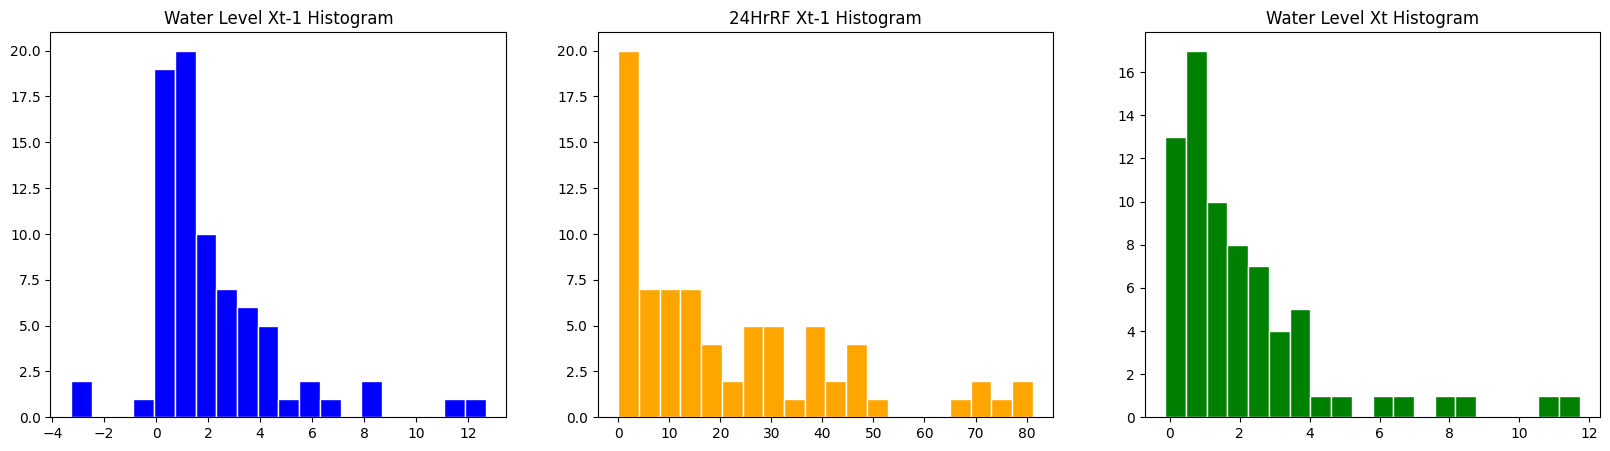

In [9]:
fig,ax=plt.subplots(1,3,figsize=(20,5))
ax[0].hist(df['Water_Level_Xt_1'],label='Water Level Xt-1',color='blue',edgecolor='white',bins=20)
ax[0].set_title('Water Level Xt-1 Histogram')
ax[1].hist(df['24HrRF_Xt_1'],label='24HrRF Xt-1',color='orange',edgecolor='white',bins=20)
ax[1].set_title('24HrRF Xt-1 Histogram')
ax[2].hist (df['Water_Level_Xt'],label='Water Level Xt',color='green',edgecolor='white',bins=20     )
ax[2].set_title('Water Level Xt Histogram')


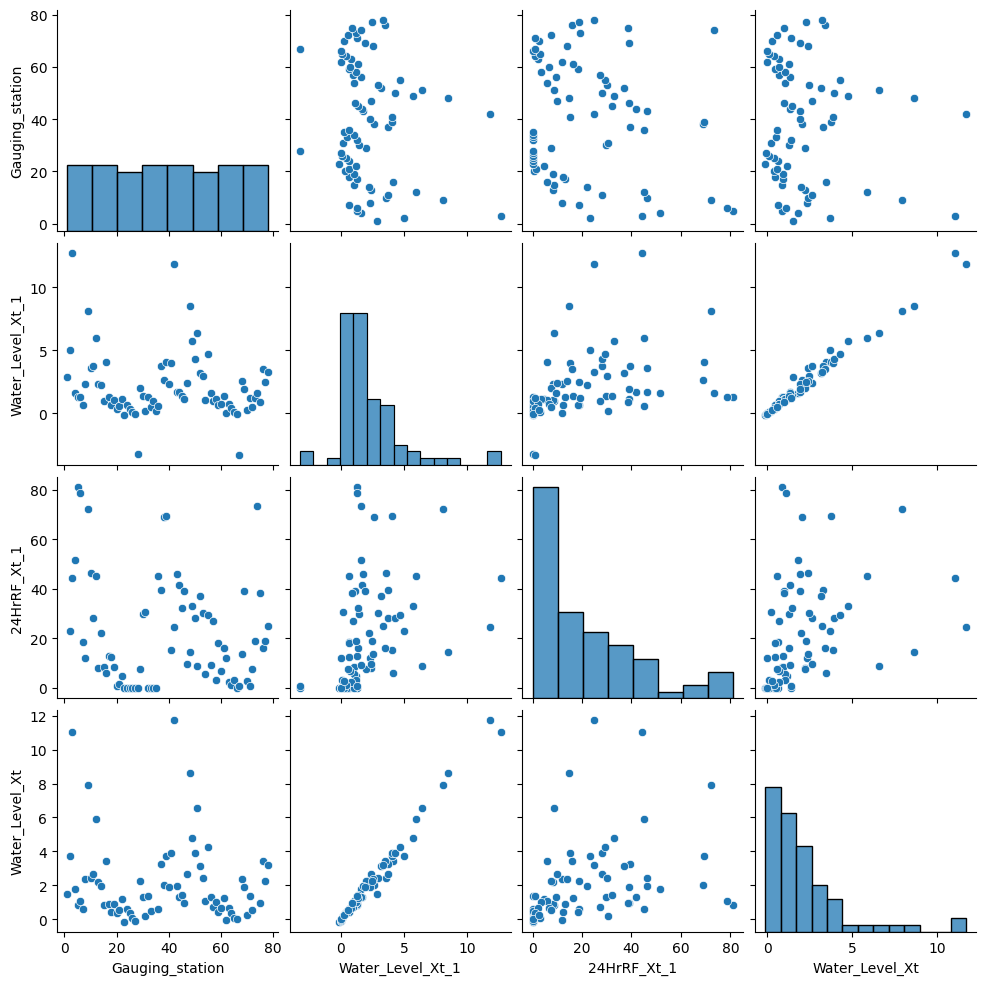

In [10]:
sns.pairplot(df)

plt.show()

In [11]:
df_clean = df.dropna(subset=["Water_Level_Xt", "24HrRF_Xt_1"]).copy()
df_clean = df_clean.drop(columns=["Gauging_station"]).reset_index(drop=True)
print(f"Rows after cleaning: {len(df_clean)}  (from {len(df)} original)")

Rows after cleaning: 70  (from 78 original)


In [12]:
print(df_clean.isnull().sum())

Water_Level_Xt_1    0
24HrRF_Xt_1         0
Water_Level_Xt      0
dtype: int64


In [13]:
df_clean.corr()

,Water_Level_Xt_1,24HrRF_Xt_1,Water_Level_Xt
Water_Level_Xt_1,1.000000,0.343091,0.991670
24HrRF_Xt_1,0.343091,1.000000,0.316074
Water_Level_Xt,0.991670,0.316074,1.000000


In [14]:
from scipy.stats import skew

skew(df_clean['Water_Level_Xt_1']), skew(df_clean['24HrRF_Xt_1']), skew(df_clean['Water_Level_Xt'])

(np.float64(2.1145177814498486),
 np.float64(1.0784399436080387),
 np.float64(2.1656997701982164))

In [15]:
x=df_clean[['Water_Level_Xt_1','24HrRF_Xt_1']]
y=df_clean['Water_Level_Xt']

print(x.shape)
print(y.shape)

(70, 2)
(70,)


In [16]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


print(x_train.shape)
print(x_test.shape) 

(56, 2)
(14, 2)


In [17]:
model=LinearRegression()
model.fit(x_train,y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:

b0 = model.intercept_      
b1 = model.coef_[0]       
b2 = model.coef_[1]         

print(f'Intercept : {b0:.6f}')
print(f'Coef X1   : {b1:.6f}')
print(f'Coef X2   : {b2:.6f}')
print(f'\nEquation: Water_Level_Xt = {b0:.4f} + {b1:.4f}*X1 + {b2:.4f}*X2')



Intercept : 0.021146
Coef X1   : 0.944768
Coef X2   : -0.002642

Equation: Water_Level_Xt = 0.0211 + 0.9448*X1 + -0.0026*X2


In [19]:
y_pred=model.predict(x_test)
y_actual=y_test

residuals=y_actual-y_pred
residuals_df=pd.DataFrame({'Actual':y_actual,'Predicted':y_pred,'Residuals':residuals}).sort_index()
print(residuals_df)

    Actual  Predicted  Residuals
0     3.71   4.683699  -0.973699
4     1.10   1.050898   0.049102
5     0.61   0.567216   0.042784
9     2.65   3.461453  -0.811453
10    5.90   5.504482   0.395518
12    1.99   2.097942  -0.107942
18    0.37   0.349966   0.020034
22    0.62   0.616350   0.003650
31    0.58   0.469135   0.110865
33    2.02   2.342510  -0.322510
45    6.56   6.044413   0.515587
49    4.27   4.364996  -0.094996
54    0.69   0.692864  -0.002864
67    3.42   3.266408   0.153592


In [20]:


r2   = r2_score(y_actual, y_pred)
mae  = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))


print(f"  R2   : {r2:.4f}   <- % variance explained")
print(f"  MAE  : {mae:.4f}  <- avg error in metres")
print(f"  RMSE : {rmse:.4f}  <- penalises large errors more")



  R2   : 0.9598   <- % variance explained
  MAE  : 0.2575  <- avg error in metres
  RMSE : 0.3959  <- penalises large errors more
